# Disease Prediction - Clean Workflow

1) Clean data
2) Train 3 models
3) Random 80/20 shuffles
4) Check whether accuracy stays 100%

In [2]:
# Imports
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [3]:
# Step 1: Load and clean data
df = pd.read_csv('Training_2.csv')
print(f'Original shape: {df.shape}')

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Drop duplicates and fully empty columns
df = df.drop_duplicates().dropna(axis=1, how='all').copy()

# Strip whitespace in object columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Choose target column robustly
prognosis_candidates = [c for c in df.columns if c.lower() == 'prognosis' or 'prognosis' in c.lower()]
object_cols = df.select_dtypes(include=['object']).columns.tolist()

if prognosis_candidates:
    target_column = prognosis_candidates[0]
elif object_cols:
    target_column = object_cols[0]
else:
    target_column = df.columns[-1]

print(f'Cleaned shape: {df.shape}')
print('Target column:', target_column)
print('Unique target classes:', df[target_column].nunique())

Original shape: (246945, 378)
Cleaned shape: (189647, 378)
Target column: diseases
Unique target classes: 773


In [4]:
# Step 2: Prepare features/target
X = df.drop(columns=[target_column]).copy()
y = df[target_column].copy()

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encode non-numeric feature columns (if any)
for col in X.select_dtypes(include=['object']).columns:
    col_le = LabelEncoder()
    X[col] = col_le.fit_transform(X[col].astype(str))

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Features shape: {X.shape}')
print(f'Classes: {len(le.classes_)}')

Features shape: (189647, 377)
Classes: 773


In [5]:
# Step 3: Train 3 models with random 80/20 shuffle splits
seeds = range(1, 6)  # 5 random shuffles for quick run
results = {
    'Random Forest': [],
    'Naive Bayes': [],
    'SVM': []
}

# Sampling for faster repeated evaluation
sample_size = min(8000, len(X))
class_counts = pd.Series(y_encoded).value_counts()
sample_stratify = y_encoded if class_counts.min() >= 2 else None

if sample_size < len(X):
    X_run, _, y_run, _ = train_test_split(
        X, y_encoded,
        train_size=sample_size,
        random_state=42,
        stratify=sample_stratify
    )
else:
    X_run, y_run = X, y_encoded

# Split strategy: use stratify only when valid
class_counts_run = pd.Series(y_run).value_counts()
split_stratify = y_run if class_counts_run.min() >= 2 else None

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X_run, y_run,
        test_size=0.2,
        shuffle=True,
        stratify=split_stratify,
        random_state=seed
    )

    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Naive Bayes': GaussianNB(),
        'SVM': SVC(kernel='linear', random_state=42)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results[name].append(acc)

print('=== Accuracy over random 80/20 shuffles ===')
print(f'Rows used for run: {len(X_run)}')
for name, scores in results.items():
    perfect_runs = sum(score == 1.0 for score in scores)
    print(
        f"{name}: mean={np.mean(scores):.4f}, min={np.min(scores):.4f}, "
        f"max={np.max(scores):.4f}, 100% runs={perfect_runs}/{len(scores)}"
    )

=== Accuracy over random 80/20 shuffles ===
Rows used for run: 8000
Random Forest: mean=0.7252, min=0.7087, max=0.7369, 100% runs=0/5
Naive Bayes: mean=0.8144, min=0.8100, max=0.8206, 100% runs=0/5
SVM: mean=0.7276, min=0.7206, max=0.7356, 100% runs=0/5


=== Model Accuracy Comparison ===
        Model  Mean Accuracy  Min Accuracy  Max Accuracy  Std Dev 100% Runs
  Naive Bayes       0.814375      0.810000      0.820625 0.003708       0/5
          SVM       0.727625      0.720625      0.735625 0.005855       0/5
Random Forest       0.725250      0.708750      0.736875 0.009549       0/5


Text(0, 0.5, 'Accuracy')

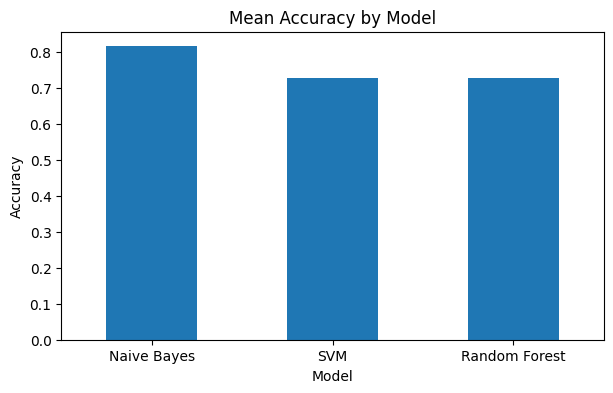

In [6]:
# Step 4: Compare model accuracy
comparison = pd.DataFrame([
    {
        'Model': name,
        'Mean Accuracy': float(np.mean(scores)),
        'Min Accuracy': float(np.min(scores)),
        'Max Accuracy': float(np.max(scores)),
        'Std Dev': float(np.std(scores)),
        '100% Runs': f"{sum(s == 1.0 for s in scores)}/{len(scores)}"
    }
    for name, scores in results.items()
]).sort_values(by='Mean Accuracy', ascending=False).reset_index(drop=True)

print('=== Model Accuracy Comparison ===')
print(comparison.to_string(index=False))

# Optional quick visual
ax = comparison.set_index('Model')['Mean Accuracy'].plot(kind='bar', figsize=(7, 4), rot=0, title='Mean Accuracy by Model')
ax.set_ylabel('Accuracy')
